# 06 · Predictions — blacklist #1

Scores the bundle from `13b_codes_bl1.ipynb`.

| arm | bundle | predictions |
|---|---|---|
| `noblack` | `nn_codes_noblack` | `predictions_noblack.csv` |
| `bl1` | `nn_codes_bl1` | `predictions_bl1.csv` |
| `bl2` | `nn_codes_bl2` | `predictions_bl2.csv` |

**This notebook is `bl1`.** It reads the `arm.json` stamp 13b wrote
beside the bundle and refuses to continue if it names a different arm
— so pointing this at the wrong weights fails loudly rather than
producing a plausible file under the wrong name.

Predictions are written into `outputs_codes/`, not the shared
`outputs/`, so the three cannot overwrite each other.

In [0]:
import pathlib, sys

ROOT = pathlib.Path.cwd()
if not (ROOT / "nn_classifier").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

import nn_classifier as nnc
from nn_classifier import artifacts, paths, predict
print(paths.describe())

[paths] scratch: /local_disk0/tmp (cluster SSD): PermissionError -- using /tmp/nn_classifier
environment: Databricks
  data dir:   /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/data
  output dir: /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs
  scratch:    /tmp/nn_classifier  (117 GB free)
  device:     cpu


## 0 · Pick a bundle, and work out how it must be fed

`BUNDLE` is an explicit path rather than `paths.output_dir() / name`.
The arms that changed the cleaning wrote to their own directories so
they could not overwrite each other, which means the shared `outputs/`
does not contain them. Pointing directly avoids having to set
`NN_CLASSIFIER_OUTPUT_DIR` here — which would also redirect where this
notebook writes its predictions.

In [0]:
# %pip install torch

In [0]:
# ---------------------------------------------------------------------
# The three settings for this run.
# ---------------------------------------------------------------------

# =====================================================================
# ARM REGISTRY -- identical in all six notebooks. Do not edit per file.
#
# Every path derives from ARM, so a bundle, a blacklist and a
# predictions file cannot end up belonging to different arms.
# =====================================================================
ARMS = {
    "noblack": {"label": "no blacklist", "blacklist": None},
    "bl1":     {"label": "blacklist #1", "blacklist": "blacklist_1.txt"},
    "bl2":     {"label": "blacklist #2", "blacklist": "blacklist_2.txt"},
}

ARM = "bl1"      # <- the only line that differs between arms
assert ARM in ARMS, f"ARM={ARM!r}; expected one of {list(ARMS)}"

BLACKLIST_FILE = ARMS[ARM]["blacklist"]
BLACKLIST_SCOPE = "train"          # "train" | "all" -- see below
BUNDLE_NAME = f"nn_codes_{ARM}"
ARM_LABEL = ARMS[ARM]["label"]

ARM_OUTPUT_DIR = ROOT / "outputs_codes"
BUNDLE = ARM_OUTPUT_DIR / BUNDLE_NAME
PREDICTIONS_FILE = f"predictions_{ARM}.csv"

VENDOR_SOURCE_COL = "Global Vendno"

# The identifier in the file being scored. `score()` now raises if this
# is not a real column -- it used to be dropped silently, so the output
# came back with nothing to join on. Set to None to score without one.
ID_COL = "ID"

# Extra columns to carry through to the output, for joining or review.
CARRY_COLS = []

# True  -> every row keeps all four predicted levels.
# False -> the cascade blanks levels below the confidence each row
#          earned, and adds an `Assigned Depth` column.
ASSIGN_ALL = True

# ---------------------------------------------------------------------

if not BUNDLE.exists():
    raise FileNotFoundError(
        f"No bundle at {BUNDLE}.\n"
        f"  Directories present under {ROOT}:\n    "
        + "\n    ".join(sorted(
            str(p.relative_to(ROOT)) for p in ROOT.glob("outputs*") if p.is_dir()))
    )

# The stamp 13b wrote. A bundle name is easy to mistype into the
# wrong notebook; this is what makes that impossible to miss.
import json
_stamp_path = BUNDLE / "arm.json"
if _stamp_path.exists():
    _stamp = json.loads(_stamp_path.read_text(encoding="utf-8"))
    if _stamp.get("arm") != ARM:
        raise RuntimeError(
            f"{BUNDLE.name} was produced by arm {_stamp.get('arm')!r}, but "
            f"this notebook is {ARM!r}. Open 06_predict_{_stamp.get('arm')}"
            ".ipynb, or fix ARM here."
        )
    print(f"arm stamp : {_stamp['arm']} ({_stamp['label']}), "
          f"blacklist {_stamp['blacklist_file'] or 'none'}, "
          f"{_stamp['train_rows']:,} train rows, "
          f"full-path {_stamp['full_path_accuracy']:.4f}")
else:
    print("  >> no arm.json beside this bundle; provenance unverified")

print(artifacts.describe_bundle(BUNDLE))
bundle = artifacts.load_bundle(BUNDLE)
levels = list(bundle["hierarchy"].level_columns)

arm stamp : bl1 (blacklist #1), blacklist blacklist_1.txt, 546,333 train rows, full-path 0.8226
bundle:        /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/nn_codes_bl1
created:       2026-09-29T02:12:34+00:00
model:         MultiHeadSparseInputMLP (torch)
levels:        ['Level 1 ID', 'Level 2 ID', 'Level 3 ID', 'Level 4 ID']
classes:       [23, 154, 716, 3512]
valid paths:   3,512
training rows: 546333
thresholds:    {'1': 0.37, '2': 0.95, '3': 0.99, '4': 0.95}  (joint prefix)
per-level:     {'1': 0.05, '2': 0.55, '3': 0.74, '4': 0.83}  <- operative
notes:         Arm bl1 (blacklist #1). Vendor + Prodcat + UNSPSC + Prodline markers.
  path_accuracy: 0.8226396441459656
  joint_ece: 0.07646891802848538
  default_threshold: 0.6
  Level 1 ID accuracy: 0.9444602131843567
  Level 2 ID accuracy: 0.9229906797409058
  Level 3 ID accuracy: 0.8857301473617554
  Level 4 ID accuracy: 0.8241547346115112
[artifacts] loaded MultiHeadSparseInp

In [0]:
# Does this bundle need the vendor marker? Read it from the config the
# bundle was saved with, rather than remembering which arm produced it.
saved_cfg = bundle.get("config")
NEEDS_VENDOR = bool(getattr(getattr(saved_cfg, "cleaning", None),
                            "attach_vendor", False))
TRAINED_ON_COL = getattr(getattr(saved_cfg, "data", None), "vendor_col", None)

# `score(vendor_col=...)` takes the column name, or False to score
# without a marker at all.
VENDOR_COL = VENDOR_SOURCE_COL if NEEDS_VENDOR else False

print(f"trained with a vendor marker : {NEEDS_VENDOR}")
if NEEDS_VENDOR:
    print(f"  training used column       : {TRAINED_ON_COL!r}")
    print(f"  scoring will use           : {VENDOR_COL!r}")
    print("  attach_vendor_token strips and de-spaces the value itself,")
    print("  and the vectorizer lowercases, so the raw column is fine.")
else:
    print("  scoring without a marker")
print()
print(f"levels     : {levels}")
print(f"assign all : {ASSIGN_ALL}")

trained with a vendor marker : False
  scoring without a marker

levels     : ['Level 1 ID', 'Level 2 ID', 'Level 3 ID', 'Level 4 ID']
assign all : True


## 1 · A handful of descriptions, by hand

Raw text exactly as it arrives — no pre-cleaning. The bundle's cleaner
does that, which is the point.

The last two rows are deliberate: one with nothing readable, one with a
blank vendor. A blank vendor gets no marker at all rather than a bare
`VND_`, so it is the case worth seeing before trusting a batch.

In [0]:
samples = pd.DataFrame({
    "ID": [f"S{i}" for i in range(1, 9)],
    "Global Vendno": ["100123", "100123", "204881", "204881",
                      "311907", "311907", "100123", ""],
    "FullDesc": [
        "QJX8A TORQUE HEAD BOXEND 1-1/4X3-1/2",
        "VALVE BALL 2IN BRASS THREADED",
        "GLOVE NITRILE DISPOSABLE BLUE LARGE 100/BX",
        "SAFETY GLASSES CLEAR ANTI-FOG",
        "END MILL 1/2IN 4 FLUTE CARBIDE TIALN",
        "BEARING BALL DEEP GROOVE 6203-2RS",
        "XK9920-AA",                     # nothing readable
        "HOSE HYDRAULIC 1/2IN 3000PSI",  # no vendor
    ],
})

scored = predict.score(
    str(BUNDLE), samples,
    text_col="FullDesc", id_col="ID",   # the samples do have one
    vendor_col=VENDOR_COL,
    joint_mode="independent",
    predict_all_levels=True,
    use_cascade=not ASSIGN_ALL,
    min_known_tokens=2,
    bundle=bundle,
)

cols = (["ID", "FullDesc", "n_tokens", "known_share"]
        + [f"Predicted {c}" for c in levels]
        + [f"{c} Confidence" for c in levels]
        + ["Confidence", "Path Evidence", "Assigned Depth",
           "Needs Review", "Review Reason"])
scored[[c for c in cols if c in scored.columns]]

[predict] 7/8 rows have at least 2 recognisable token(s)
[predict] 7 auto-assigned, 1 flagged for review (12.5%)


,ID,FullDesc,n_tokens,known_share,Predicted Level 1 ID,Predicted Level 2 ID,Predicted Level 3 ID,Predicted Level 4 ID,Level 1 ID Confidence,Level 2 ID Confidence,Level 3 ID Confidence,Level 4 ID Confidence,Confidence,Path Evidence,Needs Review,Review Reason
0,S1,TORQUE HEAD BOXEND,3,1.000000,L1-12810533,L2-12810534,L3-12810571,L4-12810794,0.964082,0.985161,0.994565,0.998956,0.999556,0.943628,False,
1,S2,VALVE BALL BRASS THREADED,4,1.000000,L1-12799358,L2-12799361,L3-12799405,L4-13531256,0.975700,0.992408,0.993170,0.982117,0.991817,0.944481,False,
2,S3,GLOVE NITRILE DISPOSABLE,3,1.000000,L1-12782908,L2-12782914,L3-12782962,L4-12783317,0.986093,0.990858,0.997428,0.992564,0.993163,0.967318,False,
3,S4,SAFETY GLASSES ANTI-FOG,4,1.000000,L1-12782908,L2-12782914,L3-12782973,L4-12783376,0.987105,0.983155,0.982352,0.971652,0.994287,0.926324,False,
4,S5,END MILL IN FLUTE CARBIDE TITANIUM-ALUMINUM-NI...,8,1.000000,L1-12783695,L2-12783699,L3-12783704,L4-12784839,0.986046,0.990408,0.994015,0.631873,0.664532,0.613386,False,
5,S6,BEARING BALL DEEP GROOVE 6203-2RS,6,0.833333,L1-12785504,L2-12785506,L3-12785517,L4-12785690,0.939183,0.981009,0.955812,0.976023,0.996375,0.859520,False,
6,S7,,0,0.000000,L1-12785504,L2-13485510,L3-13507031,L4-13507319,0.233575,0.131089,0.177432,0.292004,0.987634,0.001586,True,too few recognisable tokens
7,S8,HOSE HYDRAULIC IN 3000PSI,4,1.000000,L1-12785504,L2-12785511,L3-12785538,L4-12785602,0.983963,0.992327,0.988482,0.941597,0.967176,0.908798,False,


## 2 · A file

Chunked, because the memory cost here is the **probability matrices**,
not the model or the frame. One float per class per level per row —
4,384 floats, about 17.5 KB, on this taxonomy — and calibration makes a
second copy. At 600,000 rows that is roughly 21 GB in a single pass.

`score()` blocks by default and concatenates only the small output
frames. Chunking is exactly equivalent: nothing in the per-row path is
computed across rows.

In [0]:
TO_PREDICT = paths.data_path("to_predict.txt")

unlabelled = pd.read_csv(TO_PREDICT, delimiter="|", dtype="str")
print(f"{len(unlabelled):,} rows, columns: {list(unlabelled.columns)}")
print()

# Checked here rather than discovered by its absence in the output.
if ID_COL is not None and ID_COL not in unlabelled.columns:
    raise KeyError(
        f"ID_COL={ID_COL!r} is not in {TO_PREDICT}.\n"
        f"  Available: {list(unlabelled.columns)}\n"
        "  Set ID_COL to the right header, or None to score without one."
    )

# The check that decides whether this bundle can score this file.
if NEEDS_VENDOR:
    if VENDOR_SOURCE_COL not in unlabelled.columns:
        raise KeyError(
            f"{VENDOR_SOURCE_COL!r} is not in {TO_PREDICT}, but this bundle "
            "was trained with a vendor marker. Join the supplier in, or "
            "score this file with a no-marker bundle (10f / 12c) instead."
        )
    v = unlabelled[VENDOR_SOURCE_COL].fillna("").astype(str).str.strip()
    print(f"vendor present on : {(v != '').mean():.1%} of rows")
    print(f"distinct vendors  : {v[v != ''].nunique():,}")
    if (v != "").mean() < 0.9:
        print("  >> A blank vendor means no marker at all on that row, which")
        print("     is a shape the model saw rarely. Expect those rows to be")
        print("     weaker; `Needs Review` will not single them out.")

145,000 rows, columns: ['ID', 'ERP Cono', 'Vallen ID', 'ERP ShortDescription1', 'ERP ShortDescription2', 'Level 4 ID', 'Level 4 PPH Name', 'FullDesc', 'Global Vendno']



In [0]:
# What one block costs, before committing to the run.
block = predict.choose_chunk_size(bundle)
per_row = sum(bundle["hierarchy"].n_classes(i)
              for i in range(bundle["hierarchy"].n_levels))
print(f"block size  : {block:,} rows")
print(f"one pass    : {len(unlabelled) * per_row * 4 * 2 / 1e9:.1f} GB of "
      f"probabilities")
print(f"one block   : {block * per_row * 4 * 2 / 1e9:.2f} GB")
print()

scored = predict.score(
    str(BUNDLE), unlabelled,
    text_col="FullDesc", id_col=ID_COL,
    carry_cols=CARRY_COLS,
    vendor_col=VENDOR_COL,
    joint_mode="independent",
    predict_all_levels=True,
    use_cascade=not ASSIGN_ALL,
    min_known_tokens=2,
    bundle=bundle,          # loaded once; reloading per block dominates
)

assert len(scored) == len(unlabelled), "rows lost"
display(predict.score_summary(scored, levels))
scored.head()

block size  : 10,156 rows
one pass    : 5.1 GB of probabilities
one block   : 0.36 GB

[predict] 145,000 rows in 15 blocks of 10,156
[predict]   block 1/15 done (10,156 rows)
[predict]   block 2/15 done (20,312 rows)
[predict]   block 3/15 done (30,468 rows)
[predict]   block 4/15 done (40,624 rows)
[predict]   block 5/15 done (50,780 rows)
[predict]   block 6/15 done (60,936 rows)
[predict]   block 7/15 done (71,092 rows)
[predict]   block 8/15 done (81,248 rows)
[predict]   block 9/15 done (91,404 rows)
[predict]   block 10/15 done (101,560 rows)
[predict]   block 11/15 done (111,716 rows)
[predict]   block 12/15 done (121,872 rows)
[predict]   block 13/15 done (132,028 rows)
[predict]   block 14/15 done (142,184 rows)
[predict]   block 15/15 done (145,000 rows)
[predict] 122,740 auto-assigned, 22,260 flagged for review (15.4%)


rows,auto_assigned,needs_review,mean_confidence
145000,122740,22260,0.8731750845909119


,ID,FullDesc,n_tokens,n_known_tokens,known_share,Predicted Level 1 ID,Predicted Level 2 ID,Predicted Level 3 ID,Predicted Level 4 ID,Confidence,Path Evidence,Level 1 ID Prefix Probability,Level 1 ID Prefix Margin,Level 2 ID Prefix Probability,Level 2 ID Prefix Margin,Level 3 ID Prefix Probability,Level 3 ID Prefix Margin,Level 4 ID Prefix Probability,Level 4 ID Prefix Margin,Entropy,Level 1 ID Confidence,Level 2 ID Confidence,Level 3 ID Confidence,Level 4 ID Confidence,Needs Review,Review Reason,Predicted Level 1 Name,Predicted Level 2 Name,Predicted Level 3 Name,Predicted Level 4 Name
0,IF3JN1O5ZG2J,LEESON C6T34FB1C CAT1101 REVOLUTIONS-PER-MINUT...,7,4,0.571429,L1-12785504,L2-12785509,L3-12785530,L4-12785646,0.770902,0.004395,0.827964,0.655983,0.827493,0.657947,0.825161,0.683752,0.770902,0.704308,5.210802,0.377431,0.190945,0.222704,0.273802,False,,Bearings & Power Transmission,Motors & Motor Components,Motors,AC Motors
1,S-8677296,MOTOR ELECTRIC ALTERNATING-CURRENT 480VAC REVO...,9,9,1.000000,L1-12785504,L2-12785509,L3-12785530,L4-12785646,0.955230,0.939239,1.000000,1.000000,1.000000,1.000000,1.000000,0.999999,0.955230,0.921198,0.242270,0.993840,0.994564,0.996938,0.953144,False,,Bearings & Power Transmission,Motors & Motor Components,Motors,AC Motors
2,S-10643186,MOTOR 75HP REVOLUTIONS-PER-MINUTE TFEC,6,5,0.833333,L1-12785504,L2-12785509,L3-12785530,L4-12785646,0.939651,0.901021,1.000000,1.000000,1.000000,1.000000,0.999999,0.999998,0.939651,0.892716,0.351087,0.991738,0.980082,0.992962,0.933562,False,,Bearings & Power Transmission,Motors & Motor Components,Motors,AC Motors
3,S-9022772,MOTOR ELECTRIC ALTERNATING-CURRENT 3HP 460V RE...,9,9,1.000000,L1-12785504,L2-12785509,L3-12785530,L4-12785646,0.866067,0.841372,1.000000,1.000000,1.000000,1.000000,0.999995,0.999990,0.866067,0.812158,0.696237,0.989270,0.996835,0.996133,0.856510,False,,Bearings & Power Transmission,Motors & Motor Components,Motors,AC Motors
4,CA_VAL_6776389,MOTOR 3PH 10HP 1760RPM TOTALLY-ENCLOSED-FAN-CO...,9,9,1.000000,L1-12785504,L2-12785509,L3-12785530,L4-12785646,0.992435,0.936223,1.000000,1.000000,1.000000,1.000000,0.999993,0.999988,0.992435,0.988642,0.176264,0.995557,0.981549,0.976517,0.981119,False,,Bearings & Power Transmission,Motors & Motor Components,Motors,AC Motors


### What came back

With `ASSIGN_ALL = True` every row carries a full four-level path, so
`Needs Review` is advisory rather than structural — nothing has been
blanked. Sort or filter on `Confidence` to decide what to act on.

Matplotlib is building the font cache; this may take a moment.


thresholding on: Level 4 ID Confidence


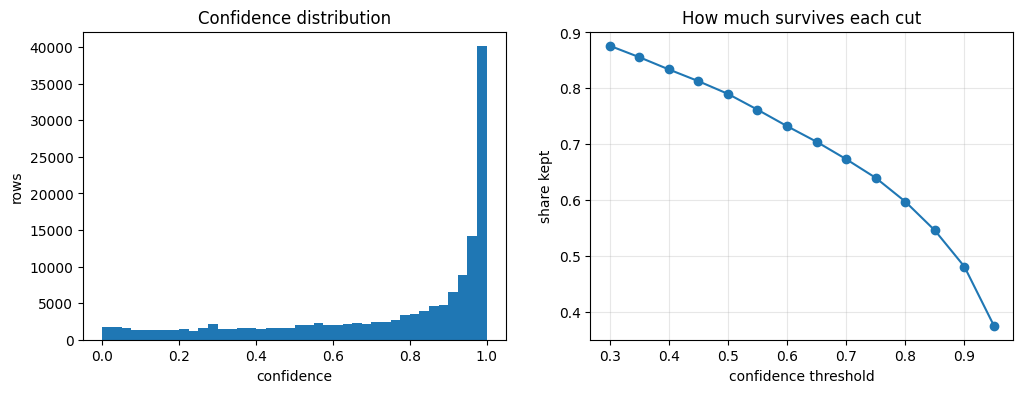

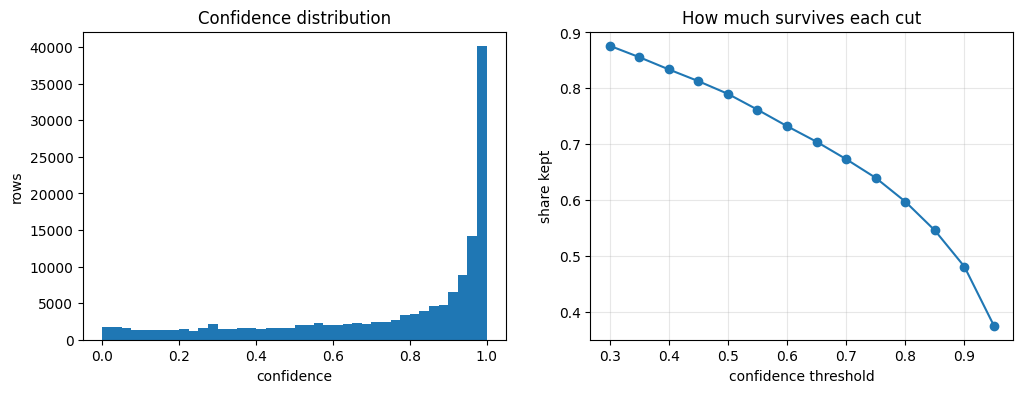

In [0]:
import matplotlib.pyplot as plt

# The per-level level-4 confidence, NOT the joint `Confidence`.
# Temperature scaling was fitted per level, so the joint figure is a
# product of four calibrated numbers and compounds their error:
# measured on validation, joint ECE 0.052 against 0.025 for level 4.
CONF_COL = f"{levels[-1]} Confidence"
if CONF_COL not in scored.columns:
    CONF_COL = "Confidence"
    print("  >> per-level confidence absent; falling back to the joint one")
print(f"thresholding on: {CONF_COL}")

conf = scored[CONF_COL].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(conf, bins=40)
axes[0].set_xlabel("confidence"); axes[0].set_ylabel("rows")
axes[0].set_title("Confidence distribution")

# Volume above each threshold. Without labels there is no accuracy to
# plot here -- the accuracy that goes with each confidence band came
# from the validation run, in notebook 03's coverage table.
grid = np.round(np.arange(0.3, 1.0, 0.05), 2)
axes[1].plot(grid, [(conf >= t).mean() for t in grid], marker="o")
axes[1].set_xlabel("confidence threshold"); axes[1].set_ylabel("share kept")
axes[1].set_title("How much survives each cut")
axes[1].grid(alpha=0.3)
fig

In [0]:
band = pd.cut(conf, [0, .5, .6, .7, .8, .9, .95, 1.0], include_lowest=True)
summary = (pd.DataFrame({"band": band})
           .groupby("band", observed=False).size().to_frame("rows"))
summary["share"] = (summary["rows"] / len(scored)).round(4)
summary["cumulative from the top"] = (
    summary["rows"][::-1].cumsum()[::-1] / len(scored)).round(4)
display(summary)

print("Accuracy per band is NOT measurable here -- these rows have no")
print("labels. Read it off notebook 03's validation coverage table and")
print("apply it to these volumes.")

rows,share,cumulative from the top
30439,0.2099,1.0
8374,0.0578,0.7901
8569,0.0591,0.7323
11017,0.076,0.6732
16873,0.1164,0.5972
15352,0.1059,0.4809
54376,0.375,0.375


Accuracy per band is NOT measurable here -- these rows have no
labels. Read it off notebook 03's validation coverage table and
apply it to these volumes.


In [0]:
out = ARM_OUTPUT_DIR / PREDICTIONS_FILE
scored.to_csv(out, index=False)
print(f"wrote {len(scored):,} rows to {out}")
print(f"arm {ARM} ({ARM_LABEL})   bundle {BUNDLE.name}   "
      f"vendor marker {NEEDS_VENDOR}   all levels {ASSIGN_ALL}")

wrote 145,000 rows to /Workspace/Users/patrick.white@vallen.com/Category Classification/NN Category Classifier/outputs_codes/predictions_bl1.csv
arm bl1 (blacklist #1)   bundle nn_codes_bl1   vendor marker False   all levels True


## If the output frame will not fit

`score()` still concatenates its blocks at the end. `score_to_csv()`
never does — it streams each block straight to disk, so peak memory is
one block whatever the input size.

```python
predict.score_to_csv(
    str(BUNDLE), unlabelled, str(paths.output_path("predictions_nn.csv")),
    text_col="FullDesc", id_col="ID",
    vendor_col=VENDOR_COL, use_cascade=not ASSIGN_ALL, bundle=bundle,
)
```

## What the output columns mean

| column | meaning |
|---|---|
| `Predicted Level N ID` / `Name` | the assigned path |
| `Confidence` | probability of the full path. **Worst-calibrated column here** — joint ECE 0.052 |
| `Level N ID Confidence` | that level's own calibrated probability for the class predicted. ECE 0.025 at level 4. **Threshold on this** |
| `Path Evidence` | the same score *un*-normalised |
| `Level N Prefix Probability` | mass summed over every path sharing that prefix |
| `Assigned Depth` | only present when `ASSIGN_ALL = False` |
| `Needs Review` / `Review Reason` | why a row would not have been auto-assigned |
| `n_tokens`, `known_share` | how much of the description the model could read |

**`Path Evidence` is the one that is easy to skip and worth keeping.**
A row where every path is implausible still produces a
confident-*looking* normalised score, because normalising divides by a
total that is itself tiny. The evidence figure is what gives that away,
and it is the column to sort by when spot-checking a batch.

## Settings that change what comes back

| | effect |
|---|---|
| `ASSIGN_ALL = False` | cascade blanks levels below the confidence each row earned |
| `vendor_col=False` | score a marked bundle without the marker — degrades every row; for diagnosis only |
| `min_known_tokens=0` | stop flagging unreadable rows. Cosmetic; nothing is blanked either way |
| `chunk_size=0` | single pass, the old behaviour. Only for small files |